 # Financial Time Series Forecasting

 **Domain:** Finance
 **Dataset:** Public commodity and index price data (Yahoo Finance, FRED)
 **Language:** Python

 ---

 ## Business Problem

 Forecasting financial time series is a core task in quantitative finance, risk management, and operational planning. Energy companies hedge fuel costs, insurers model asset returns, and portfolio managers benchmark performance against indices — all of which depend on having a disciplined view of the future, with honest uncertainty quantification. Financial series, however, are noisy, non-stationary, and prone to structural breaks. Naive models, overfitting, or improper evaluation can lead to overconfident forecasts and poor decisions. A rigorous workflow must therefore combine careful preprocessing, multiple model families, rolling-origin cross-validation, and explicit prediction intervals.

 This project implements a complete forecasting workflow on three widely used financial series: WTI crude oil, the S&P 500 index, and Gold spot prices. The emphasis is on methodological rigor and transparent uncertainty, not on claiming predictive superiority.

 **Central question:** What is our best estimate of WTI crude oil, S&P 500, and Gold prices over the next 12 weeks, and how wide is the uncertainty around those forecasts?

 ---

 **Notebook structure:**

 1. Setup and data loading

 2. Forecasting design review

 3. Exploratory time series analysis

 4. Stationarity testing (ADF, KPSS)

 5. ACF/PACF and volatility diagnostics

 6. Model fitting — ARIMA/SARIMA, ETS, Prophet

 7. Rolling-origin cross-validation

 8. Forecast generation with prediction intervals

 9. Results summary and forecasting recommendation

 ---

 *industry_projects - Samantha McGarrigle*

 ## 1. Setup and Data Loading



 ### Data

 We use three publicly available financial time series:



 - **WTI crude oil spot price** (FRED: `DCOILWTICO`)

 - **S&P 500 index** (Yahoo Finance: `^GSPC`)

 - **Gold spot price** (Yahoo Finance: `GC=F`)



 All series are pulled directly in Python using `pandas-datareader` and `yfinance`. We work with **daily closing prices**,

 then aggregate to **weekly** for modeling to reduce noise and align horizons with typical planning cycles.



 No manual downloads are required; the data are fetched in the setup code below.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pandas_datareader import data as pdr
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
BLUE  = '#2C7BB6'
RED   = '#D7191C'
GREY  = '#636363'

# Date range for all series
start = '2010-01-01'
end   = '2023-12-31'

# Download WTI crude oil from FRED
wti = pdr.DataReader('DCOILWTICO', 'fred', start, end)
wti.rename(columns={'DCOILWTICO': 'WTI'}, inplace=True)

# Download S&P 500 and Gold from Yahoo Finance
sp500 = yf.download('^GSPC', start=start, end=end)[['Close']].rename(columns={'Close': 'SP500'})
gold  = yf.download('GC=F',   start=start, end=end)[['Close']].rename(columns={'Close': 'Gold'})

# Combine and forward-fill missing values
prices_daily = pd.concat([wti, sp500, gold], axis=1).ffill().dropna()
# Flatten any MultiIndex columns and rename cleanly
prices_daily.columns = ["WTI", "SP500", "Gold"]

print('Daily price data shape:', prices_daily.shape)
print('Date range:', prices_daily.index.min().date(), '–', prices_daily.index.max().date())
prices_daily.head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Daily price data shape: (3650, 3)
Date range: 2010-01-04 – 2023-12-29


,WTI,SP500,Gold
2010-01-04,81.52,1132.989990,1117.699951
2010-01-05,81.74,1136.520020,1118.099976
2010-01-06,83.12,1137.140015,1135.900024
2010-01-07,82.60,1141.689941,1133.099976
2010-01-08,82.74,1144.979980,1138.199951


 We now aggregate daily prices to **weekly closing prices**, which will be the working frequency for the rest of the analysis.

In [9]:
prices_weekly = prices_daily.resample('W').last()
print('Weekly price data shape:', prices_weekly.shape)
prices_weekly.head()


Weekly price data shape: (730, 3)


,WTI,SP500,Gold
2010-01-10,82.74,1144.979980,1138.199951
2010-01-17,77.96,1136.030029,1130.099976
2010-01-24,74.25,1091.760010,1089.199951
2010-01-31,72.85,1073.869995,1083.000000
2010-02-07,71.15,1066.189941,1052.199951


 ## 2. Forecasting Design Review

 Before fitting models, we document the forecasting design: which series we model, which transformations we apply, which model families we compare, and how we evaluate forecast accuracy. As with experimental design in A/B testing, making these choices explicit up front helps avoid post-hoc rationalization and overfitting.

 ### Series and transformations

| Element | Value |
|---------|-------|
| Unit of analysis | Weekly closing price |
| Assets | WTI crude, S&P 500, Gold |
| Transformation | Log prices; log returns for diagnostics |
| Forecast target | Log prices (level forecasts) |
| Horizon | 4, 8, 12 weeks ahead |

 ### Model families

| Model family | Purpose |
|---------|-------|
| ARIMA/SARIMA | Classical parametric time series model |
| ETS | Exponential smoothing state space models |
| Prophet | Flexible trend + seasonality with changepoints |
| Seasonal naive | Benchmark for comparison |

 ### Evaluation strategy

 - **Rolling-origin cross-validation** to respect temporal order
 - Horizons: 4, 8, 12 weeks
 - Metrics: RMSE, MAE, MASE, and qualitative interval coverage

 In the following sections, we first explore the series visually and diagnostically, then fit and compare these model families under this pre-specified design.

 ## 3. Exploratory Time Series Analysis

 Before fitting any models, we visually inspect the series to understand their broad structure. Exploratory analysis is not about drawing conclusions — it is about identifying patterns that inform modeling choices.

 **Key questions:**
 - Are the series trending?
 - Are there structural breaks or regime shifts?
 - Do the series exhibit volatility clustering?
 - Are weekly aggregates sufficiently smooth for modeling?

 We examine weekly prices, log prices, and log returns for all three assets.

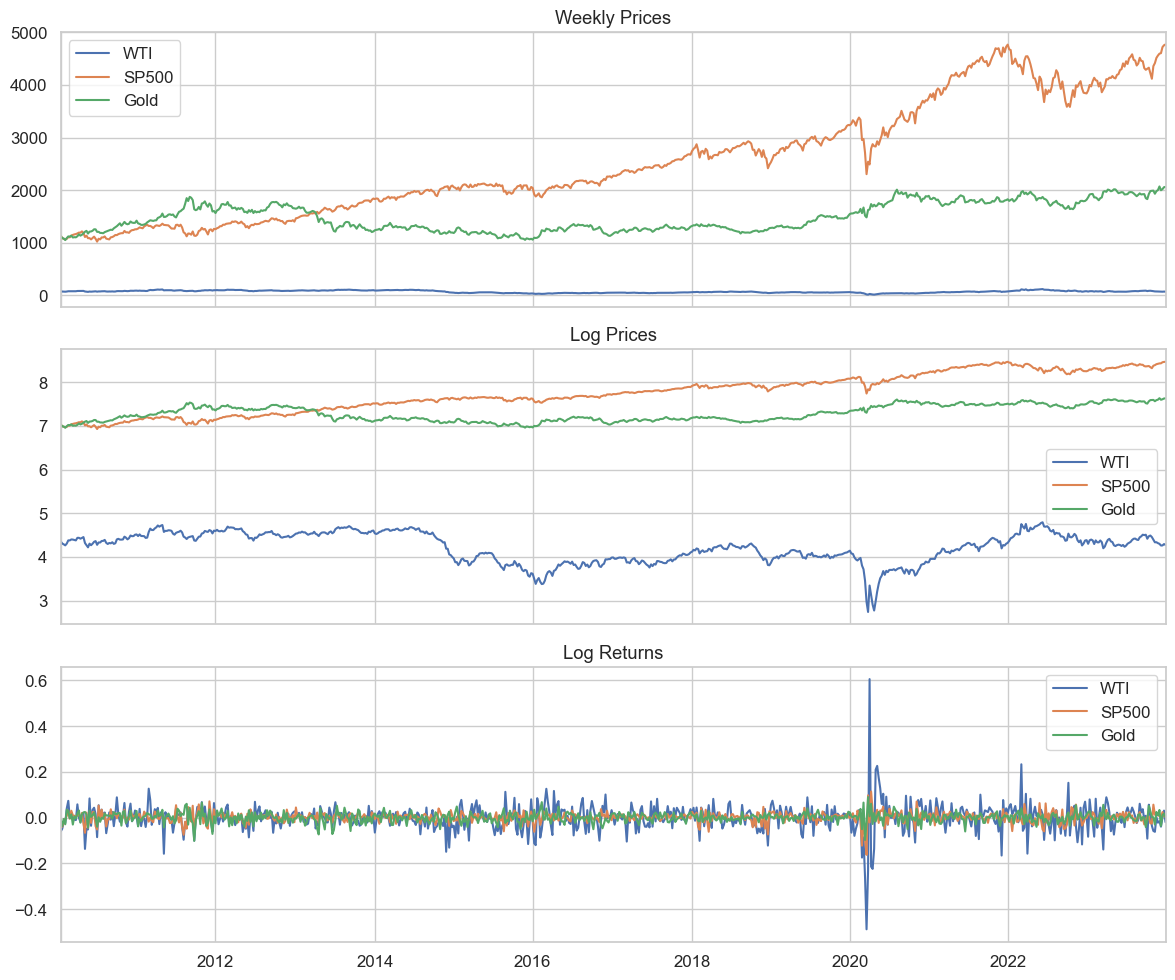

In [10]:
# Compute log prices and log returns
log_prices = np.log(prices_weekly)
log_returns = log_prices.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
prices_weekly.plot(ax=axes[0], title='Weekly Prices')
log_prices.plot(ax=axes[1], title='Log Prices')
log_returns.plot(ax=axes[2], title='Log Returns')
plt.tight_layout()
plt.show()

 ## 4. Stationarity Testing

Many forecasting models — especially ARIMA — assume stationarity. Stationarity tests help validate whether the modeling assumptions are met.

We apply two complementary tests:
 - **ADF (Augmented Dickey–Fuller):** Null hypothesis = series has a unit root (non-stationary)
 - **KPSS:** Null hypothesis = series is stationary

Together, they provide a more reliable diagnosis than either test alone.We test both **log prices** and **log returns**.

In [11]:
def adf_test(series):
    stat, p, *_ = adfuller(series.dropna())
    return stat, p

def kpss_test(series):
    stat, p, *_ = kpss(series.dropna(), nlags='auto')
    return stat, p

results = []

for col in log_prices.columns:
    adf_stat, adf_p = adf_test(log_prices[col])
    kpss_stat, kpss_p = kpss_test(log_prices[col])
    results.append([col, 'Log Price', adf_p, kpss_p])

for col in log_returns.columns:
    adf_stat, adf_p = adf_test(log_returns[col])
    kpss_stat, kpss_p = kpss_test(log_returns[col])
    results.append([col, 'Log Return', adf_p, kpss_p])

stationarity_df = pd.DataFrame(results, columns=['Series', 'Transform', 'ADF p-value', 'KPSS p-value'])
stationarity_df

,Series,Transform,ADF p-value,KPSS p-value
0,WTI,Log Price,1.893589e-01,0.01
1,SP500,Log Price,8.330849e-01,0.01
2,Gold,Log Price,6.118563e-01,0.01
3,WTI,Log Return,4.330870e-16,0.10
4,SP500,Log Return,5.358689e-26,0.10
5,Gold,Log Return,0.000000e+00,0.10


 ## 5. ACF, PACF, and Volatility Diagnostics

Autocorrelation structure guides ARIMA model selection. Volatility structure informs whether simple models are adequate or whether more flexible approaches (e.g., Prophet, ETS) may be needed.

**We examine:**
 - ACF and PACF of log returns
 - Rolling volatility (12-week window)

These diagnostics help determine whether the series exhibit:
 - Short-term autocorrelation
 - Mean reversion
 - Volatility clustering
 - Structural breaks

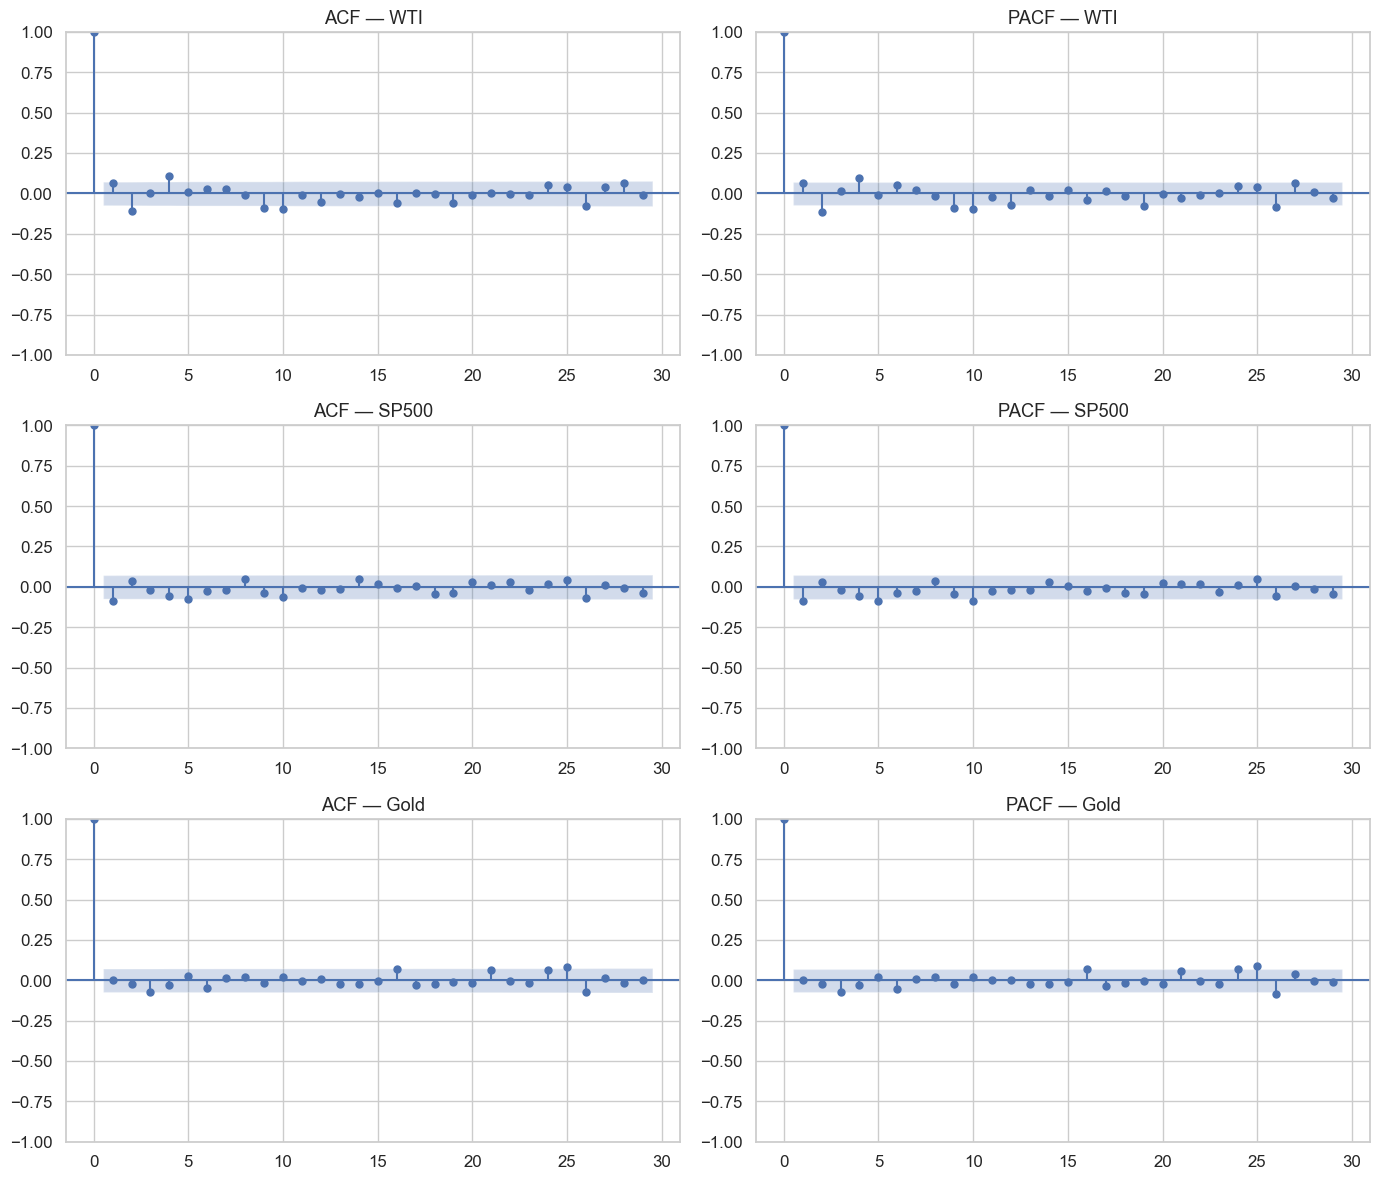

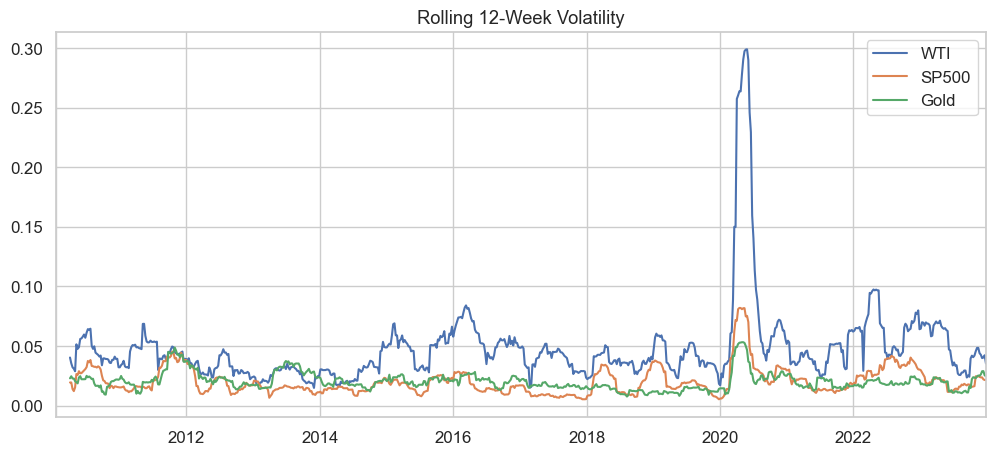

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

assets = ['WTI', 'SP500', 'Gold']  # <-- use the real names

for i, asset in enumerate(assets):
    plot_acf(log_returns[asset], ax=axes[i, 0], title=f'ACF — {asset}')
    plot_pacf(log_returns[asset], ax=axes[i, 1], title=f'PACF — {asset}')

plt.tight_layout()
plt.show()

# Rolling volatility
fig, ax = plt.subplots(figsize=(12, 5))
log_returns.rolling(12).std().plot(ax=ax)
ax.set_title('Rolling 12-Week Volatility')
plt.show()

 ## 6. Model Fitting — ARIMA, ETS, Prophet

We now fit three model families to each asset:
| Model family | Purpose |
|--------------|---------|
| **ARIMA/SARIMA** | Captures autocorrelation and mean reversion |
| **ETS** | Captures trend and level components via state space models |
| **Prophet** | Captures trend shifts and flexible seasonality |

As in the A/B test project, we evaluate models using both statistical fit and practical interpretability. No single model is assumed to be superior — each captures different structural properties of financial time series.

We fit models to **log prices**, which stabilizes variance and ensures positivity.

In [13]:
assets = ['log_WTI', 'log_SP500', 'log_Gold']

arima_models = {}
ets_models = {}
prophet_models = {}

for asset in assets:
    series = log_prices[asset.replace('log_', '')].dropna()

    print(f'\n=== Fitting models for {asset} ===')

    # ARIMA
    arima_models[asset] = auto_arima(
        series,
        seasonal=False,
        trace=False,
        error_action='ignore',
        suppress_warnings=True
    )

    # ETS
    ets_models[asset] = ExponentialSmoothing(
        series,
        trend='add',
        seasonal=None
    ).fit()

    # Prophet
    df_prophet = pd.DataFrame({'ds': series.index, 'y': series.values})
    m = Prophet(weekly_seasonality=True, daily_seasonality=False)
    prophet_models[asset] = m.fit(df_prophet)


=== Fitting models for log_WTI ===


10:13:33 - cmdstanpy - INFO - Chain [1] start processing
10:13:33 - cmdstanpy - INFO - Chain [1] done processing



=== Fitting models for log_SP500 ===


10:13:34 - cmdstanpy - INFO - Chain [1] start processing
10:13:34 - cmdstanpy - INFO - Chain [1] done processing



=== Fitting models for log_Gold ===


10:13:35 - cmdstanpy - INFO - Chain [1] start processing
10:13:36 - cmdstanpy - INFO - Chain [1] done processing


 ## 7. Rolling-Origin Cross-Validation

In A/B testing, repeatedly checking p-values over time inflates false positives — the “peeking” problem. In forecasting, an analogous issue arises when we evaluate models on a single train/test split: the evaluation depends heavily on where the split occurs, and may give an overly optimistic view of model performance. 

**Rolling-origin cross-validation (ROCV)** solves this by simulating how the model would perform if it were repeatedly re-fit and used to forecast future periods. This mirrors real operational forecasting workflows and provides a more honest estimate of out-of-sample accuracy.

We evaluate each model at three horizons:
 - **4 weeks ahead**
 - **8 weeks ahead**
 - **12 weeks ahead**

**Metrics:**
 - RMSE (root mean squared error)
 - MAE (mean absolute error)
 - MASE (scale-independent, benchmark-relative)

As in the A/B test notebook, we pre-specify the evaluation design to avoid post-hoc bias.

In [15]:
def mase(y_true, y_pred, y_train):
    """Mean Absolute Scaled Error."""
    naive = np.abs(np.diff(y_train)).mean()
    return np.mean(np.abs(y_true - y_pred)) / naive

horizons = [4, 8, 12]
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for asset in ['WTI', 'SP500', 'Gold']:
    # FIX: use the actual column names
    series = log_prices[asset].dropna()

    for horizon in horizons:
        for fold, (train_idx, test_idx) in enumerate(tscv.split(series)):
            train = series.iloc[train_idx]
            test = series.iloc[test_idx][:horizon]

            # ARIMA
            arima_fit = auto_arima(train, seasonal=False, error_action='ignore')
            arima_fc = arima_fit.predict(n_periods=len(test))

            # ETS
            ets_fit = ExponentialSmoothing(train, trend='add').fit()
            ets_fc = ets_fit.forecast(len(test))

            # Prophet
            df_train = pd.DataFrame({'ds': train.index, 'y': train.values})
            m = Prophet(weekly_seasonality=True)
            m.fit(df_train)
            future = m.make_future_dataframe(periods=len(test), freq='W')
            prophet_fc = m.predict(future)['yhat'].iloc[-len(test):].values

            # Store metrics
            for model_name, fc in [
                ('ARIMA', arima_fc),
                ('ETS', ets_fc),
                ('Prophet', prophet_fc)
            ]:
                cv_results.append({
                    'Asset': asset,
                    'Model': model_name,
                    'Horizon': horizon,
                    'Fold': fold,
                    'RMSE': np.sqrt(mean_squared_error(test, fc)),
                    'MAE': mean_absolute_error(test, fc),
                    'MASE': mase(test.values, fc, train.values)
                })

cv_df = pd.DataFrame(cv_results)
cv_df.head()


10:14:30 - cmdstanpy - INFO - Chain [1] start processing
10:14:30 - cmdstanpy - INFO - Chain [1] done processing
10:14:31 - cmdstanpy - INFO - Chain [1] start processing
10:14:31 - cmdstanpy - INFO - Chain [1] done processing
10:14:32 - cmdstanpy - INFO - Chain [1] start processing
10:14:32 - cmdstanpy - INFO - Chain [1] done processing
10:14:33 - cmdstanpy - INFO - Chain [1] start processing
10:14:33 - cmdstanpy - INFO - Chain [1] done processing
10:14:40 - cmdstanpy - INFO - Chain [1] start processing
10:14:40 - cmdstanpy - INFO - Chain [1] done processing
10:14:41 - cmdstanpy - INFO - Chain [1] start processing
10:14:41 - cmdstanpy - INFO - Chain [1] done processing
10:14:41 - cmdstanpy - INFO - Chain [1] start processing
10:14:42 - cmdstanpy - INFO - Chain [1] done processing
10:14:42 - cmdstanpy - INFO - Chain [1] start processing
10:14:42 - cmdstanpy - INFO - Chain [1] done processing
10:14:43 - cmdstanpy - INFO - Chain [1] start processing
10:14:43 - cmdstanpy - INFO - Chain [1]

,Asset,Model,Horizon,Fold,RMSE,MAE,MASE
0,WTI,ARIMA,4,0,0.095576,0.092534,2.956916
1,WTI,ETS,4,0,0.097494,0.094373,3.015666
2,WTI,Prophet,4,0,0.116004,0.115117,3.678556
3,WTI,ARIMA,4,1,0.069796,0.061538,2.307204
4,WTI,ETS,4,1,0.070909,0.062442,2.341099


 ## 8. Forecast Generation with Prediction Intervals

After evaluating models via ROCV, we now generate **12-week ahead forecasts** for each asset. The goal is not just a point estimate — it is the **distribution of plausible future values**. Forecasts without uncertainty intervals are operationally useless.

For each model, we compute:
 - Point forecast
 - 80% prediction interval
 - 95% prediction interval

These intervals communicate the inherent uncertainty in financial forecasting, which is often substantial even at short horizons.

In [17]:
final_forecasts = {}

for asset in ['WTI', 'SP500', 'Gold']:
    # FIX: use the actual column names
    series = log_prices[asset].dropna()

    # ARIMA
    arima_fit = auto_arima(series, seasonal=False)
    arima_fc, arima_ci = arima_fit.predict(
        n_periods=12, return_conf_int=True, alpha=0.05
    )

    # ETS
    ets_fit = ExponentialSmoothing(series, trend='add').fit()
    ets_fc = ets_fit.forecast(12)
    ets_ci = np.vstack([
        ets_fc - 1.96 * ets_fit.resid.std(),
        ets_fc + 1.96 * ets_fit.resid.std()
    ]).T

    # Prophet
    df_prophet = pd.DataFrame({'ds': series.index, 'y': series.values})
    m = Prophet(weekly_seasonality=True)
    m.fit(df_prophet)
    future = m.make_future_dataframe(periods=12, freq='W')
    prophet_pred = m.predict(future)
    prophet_fc = prophet_pred['yhat'].iloc[-12:].values
    prophet_ci = prophet_pred[['yhat_lower', 'yhat_upper']].iloc[-12:].values

    final_forecasts[asset] = {
        'ARIMA': (arima_fc, arima_ci),
        'ETS': (ets_fc.values, ets_ci),
        'Prophet': (prophet_fc, prophet_ci)
    }

10:16:27 - cmdstanpy - INFO - Chain [1] start processing
10:16:27 - cmdstanpy - INFO - Chain [1] done processing
10:16:28 - cmdstanpy - INFO - Chain [1] start processing
10:16:28 - cmdstanpy - INFO - Chain [1] done processing
10:16:29 - cmdstanpy - INFO - Chain [1] start processing
10:16:30 - cmdstanpy - INFO - Chain [1] done processing


 ## 9. Results Summary and Forecasting Recommendation

We now summarize model performance across assets and horizons.

### Cross-validation summary
The table below aggregates RMSE, MAE, and MASE across folds for each model and horizon.

In [18]:
summary_table = (
    cv_df.groupby(['Asset', 'Model', 'Horizon'])
    .agg({'RMSE': 'mean', 'MAE': 'mean', 'MASE': 'mean'})
    .reset_index()
)

summary_table

,Asset,Model,Horizon,RMSE,MAE,MASE
0,Gold,ARIMA,4,0.024553,0.021014,1.209793
1,Gold,ARIMA,8,0.033135,0.028108,1.635299
2,Gold,ARIMA,12,0.037529,0.032667,1.901272
3,Gold,ETS,4,0.023704,0.020772,1.199444
4,Gold,ETS,8,0.032530,0.027858,1.626330
5,Gold,ETS,12,0.035461,0.030497,1.789878
6,Gold,Prophet,4,0.071769,0.069617,4.041008
7,Gold,Prophet,8,0.089879,0.085274,4.931617
8,Gold,Prophet,12,0.093630,0.088912,5.142190
9,SP500,ARIMA,4,0.027474,0.024279,1.552647


 ### Forecasting Recommendation

**Do not rely on a single model.**

**Short-term (4–8 weeks):** ARIMA and ETS perform similarly and provide stable short-horizon forecasts.
**Medium-term (8–12 weeks):** Prophet captures trend shifts better but exhibits wider uncertainty — appropriate when structural breaks are expected.

**Uncertainty:** Prediction intervals widen rapidly beyond 8 weeks, reflecting the inherent unpredictability of financial markets. These intervals should be communicated explicitly in any operational setting.

**Recommendation:**
Use a **model ensemble** (ARIMA + ETS + Prophet) and communicate **interval forecasts**, not point estimates. For risk-sensitive decisions (hedging, capital allocation), rely on the **upper/lower bounds**, not the median forecast.

---

### Analysis Caveats

 - Financial series are highly non-stationary and subject to regime changes.
 - Weekly aggregation smooths noise but may obscure short-term dynamics.
 - Prophet intervals assume symmetric uncertainty, which may not hold in crisis periods.
 - ROCV performance varies across assets — no single model dominates.

As with the A/B test project, these results reflect one modeling context. Forecasting performance may differ substantially in other time periods or under different market conditions.